# 📓 Ordinal Encoding — Complete Jupyter Notebook

## Cell 1 — Import Libraries

- `pandas` → dataset/DataFrame ke liye
- `numpy` → numerical operations
- `OrdinalEncoder` → categorical values ko ordered numbers mein convert karega
- `matplotlib` + `seaborn` → visualization

In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import OrdinalEncoder

import matplotlib.pyplot as plt
import seaborn as sns

## Cell 2 — Definition

# Ordinal Encoding

Ordinal Encoding is a categorical data encoding technique that converts categorical values into numerical values according to their natural or meaningful order.

**Example:**

Poor < Average < Good < Excellent

| Category | Value |
|---|---|
| Poor | 0 |
| Average | 1 |
| Good | 2 |
| Excellent | 3 |

## Cell 3 — Create Dataset

In [2]:
data = {
    "student": ["A", "B", "C", "D", "E", "F", "G", "H"],

    "performance": [
        "Good", "Excellent", "Average", "Poor",
        "Good", "Excellent", "Average", "Good"
    ],

    "satisfaction": [
        "Satisfied", "Very Satisfied", "Neutral", "Dissatisfied",
        "Satisfied", "Very Satisfied", "Neutral", "Satisfied"
    ],

    "size": [
        "Large", "Medium", "Small", "Medium",
        "Large", "XL", "Small", "Medium"
    ]
}

df = pd.DataFrame(data)

df

,student,performance,satisfaction,size
0,A,Good,Satisfied,Large
1,B,Excellent,Very Satisfied,Medium
2,C,Average,Neutral,Small
3,D,Poor,Dissatisfied,Medium
4,E,Good,Satisfied,Large
5,F,Excellent,Very Satisfied,XL
6,G,Average,Neutral,Small
7,H,Good,Satisfied,Medium


## Cell 4 — Basic Dataset Information

Yahan kya check kar rahe hain?

- `shape` → rows aur columns
- `columns` → column names
- `dtypes` → data types
- `info()` → complete basic information

In [3]:
print("----- Dataset Shape -----")
print(df.shape)

print("\n----- Column Names -----")
print(df.columns)

print("\n----- Data Types -----")
print(df.dtypes)

print("\n----- Dataset Information -----")
df.info()

----- Dataset Shape -----
(8, 4)

----- Column Names -----
Index(['student', 'performance', 'satisfaction', 'size'], dtype='str')

----- Data Types -----
student         str
performance     str
satisfaction    str
size            str
dtype: object

----- Dataset Information -----
<class 'pandas.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   student       8 non-null      str  
 1   performance   8 non-null      str  
 2   satisfaction  8 non-null      str  
 3   size          8 non-null      str  
dtypes: str(4)
memory usage: 388.0 bytes


## Cell 5 — Check Unique Categories

In [4]:
print("Performance Categories:")
print(df["performance"].unique())

print("\nSatisfaction Categories:")
print(df["satisfaction"].unique())

print("\nSize Categories:")
print(df["size"].unique())

Performance Categories:
<StringArray>
['Good', 'Excellent', 'Average', 'Poor']
Length: 4, dtype: str

Satisfaction Categories:
<StringArray>
['Satisfied', 'Very Satisfied', 'Neutral', 'Dissatisfied']
Length: 4, dtype: str

Size Categories:
<StringArray>
['Large', 'Medium', 'Small', 'XL']
Length: 4, dtype: str


## Cell 6 — Check Category Counts

Ye batayega ki har category dataset mein kitni baar aayi hai.

In [5]:
print("----- Performance -----")
print(df["performance"].value_counts())

print("\n----- Satisfaction -----")
print(df["satisfaction"].value_counts())

print("\n----- Size -----")
print(df["size"].value_counts())

----- Performance -----
performance
Good         3
Excellent    2
Average      2
Poor         1
Name: count, dtype: int64

----- Satisfaction -----
satisfaction
Satisfied         3
Very Satisfied    2
Neutral           2
Dissatisfied      1
Name: count, dtype: int64

----- Size -----
size
Medium    3
Large     2
Small     2
XL        1
Name: count, dtype: int64


## Cell 7 — Understand the Natural Order

**Performance:** Poor < Average < Good < Excellent

**Satisfaction:** Dissatisfied < Neutral < Satisfied < Very Satisfied

**Size:** Small < Medium < Large < XL

⚠️ **Important:** Order hum khud define kar rahe hain because model ko natural ranking pata nahi hoti.

## Cell 8 — Define Category Orders

In [6]:
performance_order = ["Poor", "Average", "Good", "Excellent"]

satisfaction_order = ["Dissatisfied", "Neutral", "Satisfied", "Very Satisfied"]

size_order = ["Small", "Medium", "Large", "XL"]

print("Performance Order:", performance_order)
print("Satisfaction Order:", satisfaction_order)
print("Size Order:", size_order)

Performance Order: ['Poor', 'Average', 'Good', 'Excellent']
Satisfaction Order: ['Dissatisfied', 'Neutral', 'Satisfied', 'Very Satisfied']
Size Order: ['Small', 'Medium', 'Large', 'XL']


## Cell 9 — Create Ordinal Encoder

Yahan humne encoder ko bataya:

- performance → Poor < Average < Good < Excellent
- satisfaction → Dissatisfied < Neutral < Satisfied < Very Satisfied
- size → Small < Medium < Large < XL

In [7]:
encoder = OrdinalEncoder(
    categories=[
        performance_order,
        satisfaction_order,
        size_order
    ]
)

print(encoder)

OrdinalEncoder(categories=[['Poor', 'Average', 'Good', 'Excellent'],
                           ['Dissatisfied', 'Neutral', 'Satisfied',
                            'Very Satisfied'],
                           ['Small', 'Medium', 'Large', 'XL']])


## Cell 10 — Apply Ordinal Encoding

In [8]:
df[
    ["performance_encoded", "satisfaction_encoded", "size_encoded"]
] = encoder.fit_transform(
    df[["performance", "satisfaction", "size"]]
)

df

,student,performance,satisfaction,size,performance_encoded,satisfaction_encoded,size_encoded
0,A,Good,Satisfied,Large,2.0,2.0,2.0
1,B,Excellent,Very Satisfied,Medium,3.0,3.0,1.0
2,C,Average,Neutral,Small,1.0,1.0,0.0
3,D,Poor,Dissatisfied,Medium,0.0,0.0,1.0
4,E,Good,Satisfied,Large,2.0,2.0,2.0
5,F,Excellent,Very Satisfied,XL,3.0,3.0,3.0
6,G,Average,Neutral,Small,1.0,1.0,0.0
7,H,Good,Satisfied,Medium,2.0,2.0,1.0


## Cell 11 — Convert Encoded Values to Integer

`OrdinalEncoder` normally float values return karta hai (`0.0, 1.0, 2.0, 3.0`). Hum unhe integer bana sakte hain (`0, 1, 2, 3`).

In [9]:
encoded_columns = [
    "performance_encoded",
    "satisfaction_encoded",
    "size_encoded"
]

df[encoded_columns] = df[encoded_columns].astype(int)

df

,student,performance,satisfaction,size,performance_encoded,satisfaction_encoded,size_encoded
0,A,Good,Satisfied,Large,2,2,2
1,B,Excellent,Very Satisfied,Medium,3,3,1
2,C,Average,Neutral,Small,1,1,0
3,D,Poor,Dissatisfied,Medium,0,0,1
4,E,Good,Satisfied,Large,2,2,2
5,F,Excellent,Very Satisfied,XL,3,3,3
6,G,Average,Neutral,Small,1,1,0
7,H,Good,Satisfied,Medium,2,2,1


## Cell 12 — Check Encoding Result

In [10]:
print("----- Encoded Dataset -----")
print(df)

----- Encoded Dataset -----
  student performance    satisfaction    size  performance_encoded  \
0       A        Good       Satisfied   Large                    2   
1       B   Excellent  Very Satisfied  Medium                    3   
2       C     Average         Neutral   Small                    1   
3       D        Poor    Dissatisfied  Medium                    0   
4       E        Good       Satisfied   Large                    2   
5       F   Excellent  Very Satisfied      XL                    3   
6       G     Average         Neutral   Small                    1   
7       H        Good       Satisfied  Medium                    2   

   satisfaction_encoded  size_encoded  
0                     2             2  
1                     3             1  
2                     1             0  
3                     0             1  
4                     2             2  
5                     3             3  
6                     1             0  
7                    

## Cell 13 — Display Mapping

Ye bahut important cell hai.

In [11]:
print("----- Performance Mapping -----")
for category, value in zip(performance_order, range(len(performance_order))):
    print(category, "→", value)

print("\n----- Satisfaction Mapping -----")
for category, value in zip(satisfaction_order, range(len(satisfaction_order))):
    print(category, "→", value)

print("\n----- Size Mapping -----")
for category, value in zip(size_order, range(len(size_order))):
    print(category, "→", value)

----- Performance Mapping -----
Poor → 0
Average → 1
Good → 2
Excellent → 3

----- Satisfaction Mapping -----
Dissatisfied → 0
Neutral → 1
Satisfied → 2
Very Satisfied → 3

----- Size Mapping -----
Small → 0
Medium → 1
Large → 2
XL → 3


## Cell 14 — Check Encoder Classes

Ye check karne ke liye useful hai ki encoder ne kaunsi categories learn ki hain.

In [12]:
print("Encoder Categories:")

for column, categories in zip(
    ["performance", "satisfaction", "size"],
    encoder.categories_
):
    print(column, ":", categories)

Encoder Categories:
performance : ['Poor' 'Average' 'Good' 'Excellent']
satisfaction : ['Dissatisfied' 'Neutral' 'Satisfied' 'Very Satisfied']
size : ['Small' 'Medium' 'Large' 'XL']


## Cell 15 — Manual Ordinal Encoding

Ordinal Encoding manually bhi kar sakte hain.

In [13]:
performance_mapping = {
    "Poor": 0,
    "Average": 1,
    "Good": 2,
    "Excellent": 3
}

df["performance_manual"] = df["performance"].map(performance_mapping)

df[["performance", "performance_encoded", "performance_manual"]]

,performance,performance_encoded,performance_manual
0,Good,2,2
1,Excellent,3,3
2,Average,1,1
3,Poor,0,0
4,Good,2,2
5,Excellent,3,3
6,Average,1,1
7,Good,2,2


## Cell 16 — Verify Both Methods

In [14]:
result = df["performance_encoded"] == df["performance_manual"]

print("Are both methods same?")
print(result.all())

Are both methods same?
True


## Cell 17 — Encoding Visualization

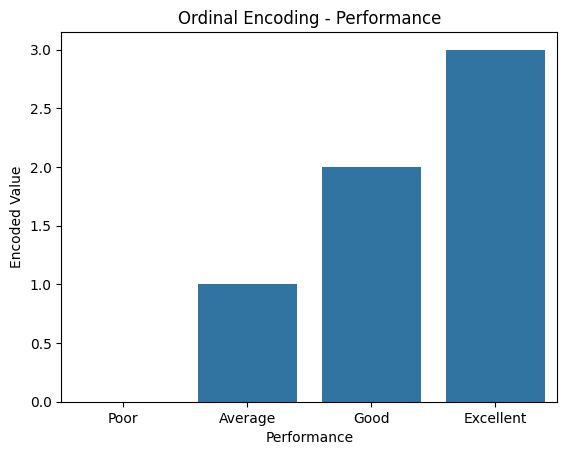

In [15]:
mapping_df = pd.DataFrame({
    "Category": performance_order,
    "Encoded_Value": range(len(performance_order))
})

sns.barplot(data=mapping_df, x="Category", y="Encoded_Value")

plt.title("Ordinal Encoding - Performance")
plt.xlabel("Performance")
plt.ylabel("Encoded Value")
plt.show()

## Cell 18 — Compare Original and Encoded Data

In [16]:
comparison = df[
    [
        "performance", "performance_encoded",
        "satisfaction", "satisfaction_encoded",
        "size", "size_encoded"
    ]
]

comparison

,performance,performance_encoded,satisfaction,satisfaction_encoded,size,size_encoded
0,Good,2,Satisfied,2,Large,2
1,Excellent,3,Very Satisfied,3,Medium,1
2,Average,1,Neutral,1,Small,0
3,Poor,0,Dissatisfied,0,Medium,1
4,Good,2,Satisfied,2,Large,2
5,Excellent,3,Very Satisfied,3,XL,3
6,Average,1,Neutral,1,Small,0
7,Good,2,Satisfied,2,Medium,1


## Cell 19 — Check Missing Values

Encoding se pehle missing values check karna important hai.

In [17]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
student                 0
performance             0
satisfaction            0
size                    0
performance_encoded     0
satisfaction_encoded    0
size_encoded            0
performance_manual      0
dtype: int64


## Cell 20 — Handling Unknown Categories

Real-world ML mein kabhi-kabhi new category aa sakti hai. Example: `Outstanding` training categories mein nahi tha. Unknown categories ko handle karne ke liye `handle_unknown="use_encoded_value"` aur `unknown_value=-1` use karte hain.

In [18]:
encoder_unknown = OrdinalEncoder(
    categories=[performance_order],
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

test_data = pd.DataFrame({
    "performance": ["Poor", "Good", "Excellent", "Outstanding"]
})

encoder_unknown.fit(df[["performance"]])

result = encoder_unknown.transform(test_data)

print(result)

[[ 0.]
 [ 2.]
 [ 3.]
 [-1.]]


`Outstanding` ko **-1** milega because ye unknown category hai.

## Cell 21 — Reverse Encoding

Kabhi-kabhi encoded numbers ko original categories mein convert karna hota hai (`0 → Poor`, `1 → Average`, ...).

In [19]:
encoded_values = df[
    ["performance_encoded", "satisfaction_encoded", "size_encoded"]
]

original_values = encoder.inverse_transform(encoded_values)

original_df = pd.DataFrame(
    original_values,
    columns=["performance", "satisfaction", "size"]
)

original_df

,performance,satisfaction,size
0,Good,Satisfied,Large
1,Excellent,Very Satisfied,Medium
2,Average,Neutral,Small
3,Poor,Dissatisfied,Medium
4,Good,Satisfied,Large
5,Excellent,Very Satisfied,XL
6,Average,Neutral,Small
7,Good,Satisfied,Medium


## Cell 22 — Final Dataset

In [20]:
print("----- Final Dataset -----")
df

----- Final Dataset -----


,student,performance,satisfaction,size,performance_encoded,satisfaction_encoded,size_encoded,performance_manual
0,A,Good,Satisfied,Large,2,2,2,2
1,B,Excellent,Very Satisfied,Medium,3,3,1,3
2,C,Average,Neutral,Small,1,1,0,1
3,D,Poor,Dissatisfied,Medium,0,0,1,0
4,E,Good,Satisfied,Large,2,2,2,2
5,F,Excellent,Very Satisfied,XL,3,3,3,3
6,G,Average,Neutral,Small,1,1,0,1
7,H,Good,Satisfied,Medium,2,2,1,2


## Cell 23 — Remove Manual Extra Column

Agar final ML dataset banana hai:

In [21]:
df = df.drop(columns=["performance_manual"])

df

,student,performance,satisfaction,size,performance_encoded,satisfaction_encoded,size_encoded
0,A,Good,Satisfied,Large,2,2,2
1,B,Excellent,Very Satisfied,Medium,3,3,1
2,C,Average,Neutral,Small,1,1,0
3,D,Poor,Dissatisfied,Medium,0,0,1
4,E,Good,Satisfied,Large,2,2,2
5,F,Excellent,Very Satisfied,XL,3,3,3
6,G,Average,Neutral,Small,1,1,0
7,H,Good,Satisfied,Medium,2,2,1


## Cell 24 — Save Encoded Dataset

File banegi: `ordinal_encoded_dataset.csv`

In [22]:
df.to_csv("ordinal_encoded_dataset.csv", index=False)

print("Dataset saved successfully!")

Dataset saved successfully!


## Cell 25 — Final Verification

In [23]:
print("----- Final Shape -----")
print(df.shape)

print("\n----- Final Columns -----")
print(df.columns.tolist())

print("\n----- Final Data Types -----")
print(df.dtypes)

print("\n----- Final Dataset -----")
print(df)

----- Final Shape -----
(8, 7)

----- Final Columns -----
['student', 'performance', 'satisfaction', 'size', 'performance_encoded', 'satisfaction_encoded', 'size_encoded']

----- Final Data Types -----
student                   str
performance               str
satisfaction              str
size                      str
performance_encoded     int64
satisfaction_encoded    int64
size_encoded            int64
dtype: object

----- Final Dataset -----
  student performance    satisfaction    size  performance_encoded  \
0       A        Good       Satisfied   Large                    2   
1       B   Excellent  Very Satisfied  Medium                    3   
2       C     Average         Neutral   Small                    1   
3       D        Poor    Dissatisfied  Medium                    0   
4       E        Good       Satisfied   Large                    2   
5       F   Excellent  Very Satisfied      XL                    3   
6       G     Average         Neutral   Small            

## 📌 Complete Concept Summary

**Ordinal Encoding workflow:**

```
Categorical Data
       ↓
Check whether natural order exists
       ↓
Define correct order
       ↓
Create OrdinalEncoder
       ↓
fit_transform()
       ↓
Numerical Ordered Data
```

**Example:** Poor → 0, Average → 1, Good → 2, Excellent → 3